# A equação de Schrödinger no laboratório — sistemas canônicos

**Para: Pedro.** Aqui o laboratório resolve os sistemas clássicos de
livro-texto — e você vê a mecânica quântica "acontecer": energias
quantizadas, nós, penetração em região proibida, anarmonicidade e
tunelamento. Tudo com o MESMO Numerov do espalhamento, agora caçando
autovalores ($E$ tal que $u$ morre nas duas pontas).

$$u''(x) = 2\,[V(x) - E]\,u(x), \qquad u(x_0) = u(x_1) = 0$$

O truque do solver (`src/schrodinger.py`): o **teorema da oscilação** —
o número de nós de $u$ conta quantos autovalores existem abaixo de $E$.
Bisseção nos nós encurrala cada $E_n$; `brentq` refina.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import schrodinger as sq   # arquivo ao lado deste notebook
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
print('pronto!')

pronto!


---
## 1. Oscilador harmônico — a armadilha dos átomos frios

$$V(x) = \tfrac{1}{2}x^2 \qquad\Rightarrow\qquad E_n = n + \tfrac{1}{2} \quad (\hbar = m = \omega = 1)$$

🗣️ Cada símbolo: $n$ = número de nós da função de onda; o $\tfrac12$ é a
**energia de ponto zero** (nem no estado fundamental a partícula "para",
por Heisenberg). Níveis igualmente espaçados = assinatura do oscilador.

**Por que isso é o seu mestrado:** a armadilha óptica que segura os
átomos de ³⁹K é, perto do fundo, exatamente este potencial. Confinar
3D→2D = deixar UMA das frequências enorme, congelando esse grau de
liberdade no estado de ponto zero.

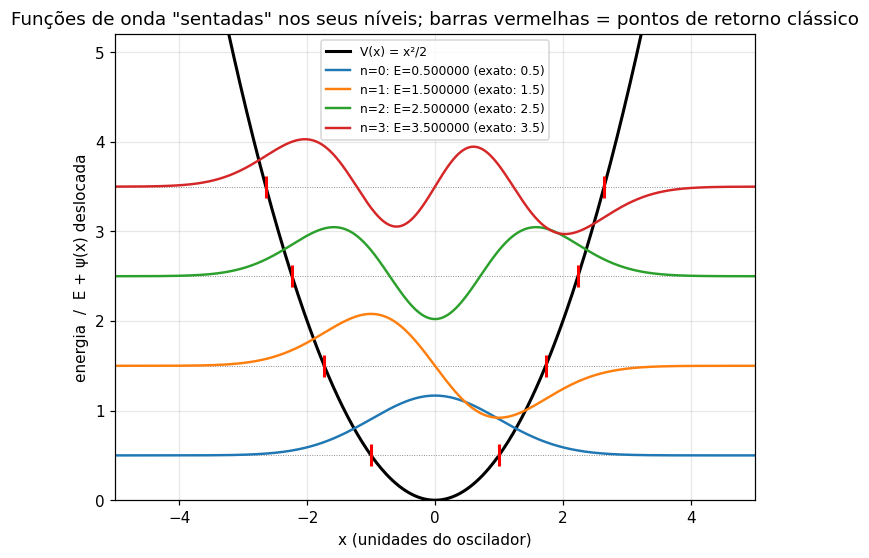

In [2]:
# 🔧 MEXA AQUI: quantos estados mostrar
n_mostrar = 4

niveis = sq.autovalores(sq.V_oscilador, -8, 8, 0.0, n_mostrar + 1.0,
                        n_estados=n_mostrar, dx=4e-3)
xx = np.linspace(-5, 5, 400)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(xx, sq.V_oscilador(xx), 'k-', lw=2, label='V(x) = x²/2')
for E, n in niveis:
    x, u = sq.autofuncao(sq.V_oscilador, E, -8, 8, dx=4e-3)
    m = np.abs(x) <= 5
    ax.axhline(E, color='gray', lw=0.6, ls=':')
    ax.plot(x[m], E + 0.9*u[m], lw=1.6,
            label=f'n={n}: E={E:.6f} (exato: {n+0.5})')
    # pontos de retorno clássico: V(x)=E -> x = sqrt(2E)
    xt = np.sqrt(2*E)
    ax.plot([-xt, xt], [E, E], 'r|', ms=14, mew=2)
ax.set_ylim(0, n_mostrar + 1.2); ax.set_xlim(-5, 5)
ax.set_xlabel('x (unidades do oscilador)')
ax.set_ylabel('energia  /  E + ψ(x) deslocada')
ax.set_title('Funções de onda "sentadas" nos seus níveis; barras vermelhas = pontos de retorno clássico')
ax.legend(fontsize=8, loc='upper center')
plt.show()

📊 **Como ler:** EIXO X = posição; EIXO Y = energia, e cada função de
onda está desenhada deslocada para cima até seu nível $E_n$ (convenção
padrão de livro). As **barras vermelhas** são os pontos de retorno
clássico ($V=E$): note a cauda da função de onda VAZANDO além deles —
região classicamente proibida, mas quanticamente acessível (mesma
matemática do tunelamento da §4). Conte os nós: $n$ exatamente.

🔧 experimentos: `n_mostrar = 8` (o espaçamento continua 1, sempre);
troque `V_oscilador` por `lambda x: 0.5*x**2 + 0.1*x**4` e veja os
níveis DEIXAREM de ser igualmente espaçados (anarmonicidade).

---
## 2. Átomo de hidrogênio — a mesma equação radial do espalhamento

$$V(r) = -\frac{1}{r} \qquad\Rightarrow\qquad E_n = -\frac{1}{2n^2} \;\text{(unidades atômicas: 1 u.a.} = 27{,}2\ \text{eV)}$$

Aqui é a MESMA $u(r) = r\psi(r)$ do laboratório, com $u(0)=0$ — só que
com $E<0$ e caçando estados ligados em vez de espalhamento.

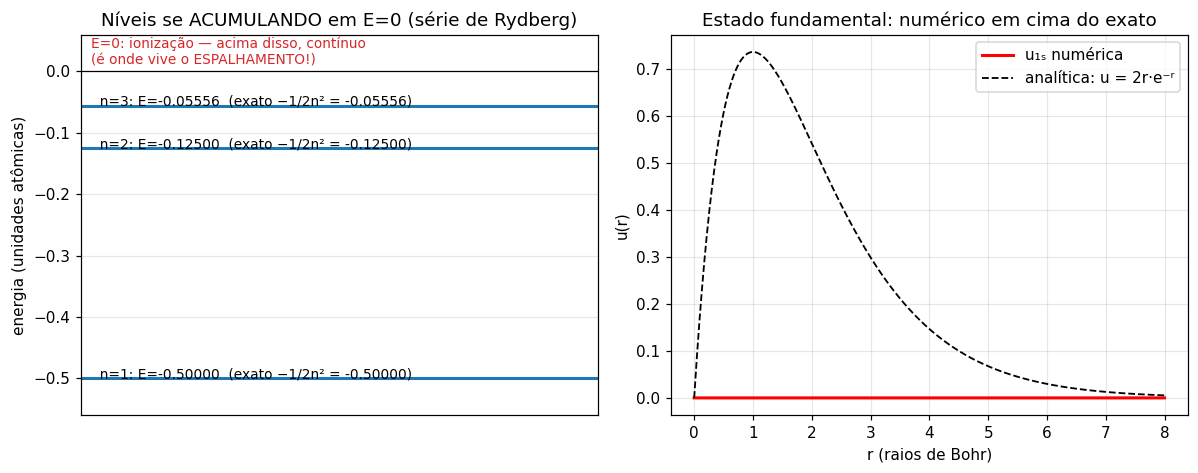

In [3]:
niveis = sq.autovalores(sq.V_hidrogenio(0), 1e-6, 60, -0.6, -0.03,
                        n_estados=3, dx=2e-3)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
for E, nos in niveis:
    n = nos + 1
    ax1.axhline(E, lw=2)
    ax1.annotate(f'  n={n}: E={E:.5f}  (exato −1/2n² = {-0.5/n**2:.5f})',
                 (0.02, E), fontsize=9)
ax1.axhline(0, color='k', lw=0.8)
ax1.annotate('E=0: ionização — acima disso, contínuo\n(é onde vive o ESPALHAMENTO!)',
             (0.02, 0.012), fontsize=9, color='tab:red')
ax1.set_ylim(-0.56, 0.06); ax1.set_xticks([])
ax1.set_ylabel('energia (unidades atômicas)')
ax1.set_title('Níveis se ACUMULANDO em E=0 (série de Rydberg)')
# 1s numérica vs analítica
E1 = niveis[0][0]
r, u = sq.autofuncao(sq.V_hidrogenio(0), E1, 1e-6, 60, dx=2e-3)
m = r <= 8
ax2.plot(r[m], u[m], 'r-', lw=2, label='u₁ₛ numérica')
ax2.plot(r[m], 2*r[m]*np.exp(-r[m]), 'k--', lw=1.2,
         label='analítica: u = 2r·e⁻ʳ')
ax2.set_xlabel('r (raios de Bohr)'); ax2.set_ylabel('u(r)')
ax2.set_title('Estado fundamental: numérico em cima do exato')
ax2.legend()
plt.tight_layout(); plt.show()

📊 **Como ler:** à esquerda, os níveis −0,5, −0,125, −0,056 u.a.
apertando-se contra $E=0$ — infinitos estados cabem porque $-1/r$ tem
alcance longo (compare: nossos potenciais nucleares de curto alcance têm
0 ou 1!). Acima de zero está o contínuo — o mundo do espalhamento, que
é o resto deste laboratório. À direita, a $u_{1s}$ numérica coincide com
$2re^{-r}$.

---
## 3. Morse — a molécula diatômica (primo realista do nosso LJ)

$$V(r) = D\left(1 - e^{-a(r-r_e)}\right)^2 - D
\qquad\Rightarrow\qquad
E_n = -D + \omega\left(n+\tfrac12\right) - \frac{\omega^2 (n+\tfrac12)^2}{4D},\quad \omega = a\sqrt{2D}$$

O termo quadrático é a **anarmonicidade**: os níveis se apertam ao
subir, e o poço comporta um número FINITO deles ($n \le \sqrt{2D}/a - \tfrac12$)
— diferente do oscilador (infinitos) e igualzinho ao He₂/LJ do
laboratório.

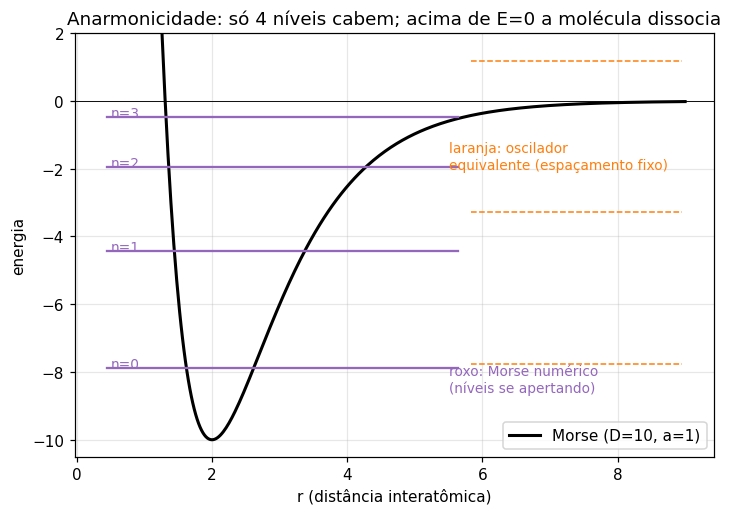

n=0: E_num=-7.88893  E_analitico=-7.88893
n=1: E_num=-4.41680  E_analitico=-4.41680
n=2: E_num=-1.94466  E_analitico=-1.94466
n=3: E_num=-0.47252  E_analitico=-0.47252


In [4]:
D, a_m, re = 10.0, 1.0, 2.0
V = sq.V_morse(D, a_m, re)
niveis = sq.autovalores(V, 0.05, 12, -9.99, -0.02, n_estados=4, dx=4e-3)
rr = np.linspace(0.4, 9, 400)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(rr, V(rr), 'k-', lw=2, label='Morse (D=10, a=1)')
w = a_m*np.sqrt(2*D)
for E, n in niveis:
    ax.axhline(E, color='tab:purple', lw=1.5,
               xmin=0.05, xmax=0.6)
    E_h = -D + w*(n+0.5)           # oscilador equivalente (sem anarmonicidade)
    ax.axhline(E_h, color='tab:orange', lw=1, ls='--', xmin=0.62, xmax=0.95)
    ax.annotate(f'n={n}', (0.5, E), fontsize=9, color='tab:purple')
ax.annotate('roxo: Morse numérico\n(níveis se apertando)', (5.5, -8.6),
            fontsize=9, color='tab:purple')
ax.annotate('laranja: oscilador\nequivalente (espaçamento fixo)', (5.5, -2.0),
            fontsize=9, color='tab:orange')
ax.axhline(0, color='k', lw=0.6)
ax.set_ylim(-10.5, 2); ax.set_xlabel('r (distância interatômica)')
ax.set_ylabel('energia'); ax.set_title(
    f'Anarmonicidade: só {sq.n_max_morse(D, a_m)+1} níveis cabem; acima de E=0 a molécula dissocia')
ax.legend(loc='lower right')
plt.show()
for E, n in niveis:
    print(f'n={n}: E_num={E:.5f}  E_analitico={sq.E_morse(n, D, a_m):.5f}')

📊 **Como ler:** os níveis roxos (numéricos) se APERTAM ao subir — o
poço fica "largo" perto da dissociação. Compare com o laranja (oscilador
com o mesmo fundo): espaçamento constante. Essa diferença é o que um
espectro vibracional molecular mede. Acima de $E=0$: dissociação — de
novo o contínuo, de novo espalhamento.

---
## 4. Tunelamento — atravessar sem energia para isso

Barreira retangular (altura $V_0$, largura $L$), $E < V_0$:

$$T(E) = \left[1 + \frac{V_0^2 \sinh^2(\kappa L)}{4E(V_0 - E)}\right]^{-1},
\qquad \kappa = \sqrt{2(V_0 - E)}$$

🗣️ $T$ = probabilidade de ATRAVESSAR. Classicamente $T=0$ para $E<V_0$
e $T=1$ acima. Quanticamente: exponencialmente pequeno mas NÃO nulo
abaixo, e (surpresa) menor que 1 logo acima — com oscilações.

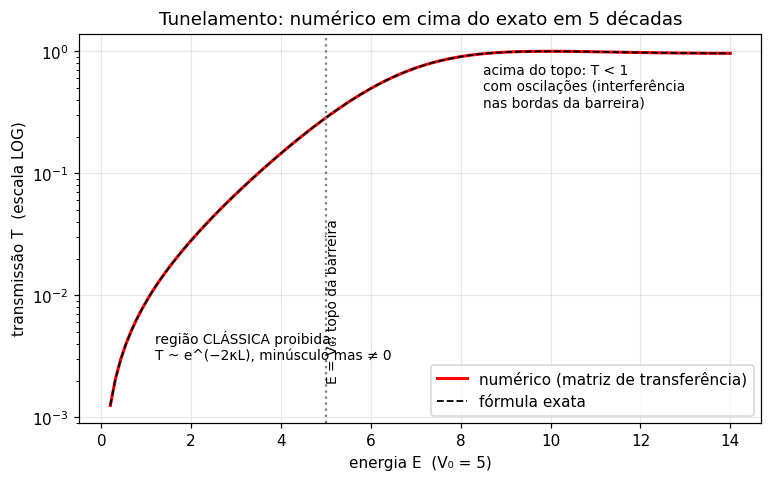

In [5]:
V0, L = 5.0, 1.0
Es = np.linspace(0.2, 14, 120)
T_num = [sq.transmissao(sq.V_barreira(V0, L), E, -0.5, 1.5, dx=1e-4)
         for E in Es]
T_ana = [sq.T_barreira_analitico(E, V0, L) for E in Es]
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.semilogy(Es, T_num, 'r-', lw=2, label='numérico (matriz de transferência)')
ax.semilogy(Es, T_ana, 'k--', lw=1.2, label='fórmula exata')
ax.axvline(V0, color='gray', ls=':')
ax.annotate('E = V₀: topo da barreira', (V0, 2e-3), rotation=90, fontsize=9)
ax.annotate('região CLÁSSICA proibida:\nT ~ e^(−2κL), minúsculo mas ≠ 0',
            (1.2, 3e-3), fontsize=9)
ax.annotate('acima do topo: T < 1\ncom oscilações (interferência\nnas bordas da barreira)',
            (8.5, 0.35), fontsize=9)
ax.set_xlabel('energia E  (V₀ = 5)')
ax.set_ylabel('transmissão T  (escala LOG)')
ax.set_title('Tunelamento: numérico em cima do exato em 5 décadas')
ax.legend(loc='lower right')
plt.show()

📊 **Como ler:** eixo y LOG — a curva varre 5 ordens de grandeza.
Abaixo de $V_0$: queda exponencial (é o mesmo $e^{-\kappa x}$ da cauda
do oscilador e da função de onda do dêuteron!). Acima: $T$ oscila e só
tende a 1 — as bordas da barreira refletem como interfaces de vidro
refletem luz. Os máximos ($T=1$) são **ressonâncias de transmissão**.

🔧 experimentos: dobre `L` e veja o tunelamento despencar (exponencial
na LARGURA); troque a barreira por um poço (`V0=-5`) e veja ressonâncias
acima do poço.

---
## O mapa: cada sistema simples → um pedaço do mestrado

| Sistema | O que ensina | Onde aparece no mestrado |
|---|---|---|
| Oscilador | quantização, ponto zero, região proibida | a ARMADILHA; confinamento 3D→2D = ω_z ≫ ω_⊥ |
| Hidrogênio | mesma u(r) radial; contínuo em E>0 | o formalismo inteiro do laboratório |
| Morse | anarmonicidade, nº finito de níveis, dissociação | dímeros reais (He₂, Feshbach molecules do ³⁹K) |
| Tunelamento | e^{-κx} atravessando barreiras | caudas de funções de onda; estados ligados rasos |

E o fio condutor: **estados ligados ($E<0$) e espalhamento ($E>0$) são
as duas metades da mesma equação** — o laboratório agora resolve as duas.